In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

IMAGE_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_folder = r"/content/Potato_dataset/Potato_disease_detection_dataset/Training"
val_folder   = r"/content/Potato_dataset/Potato_disease_detection_dataset/Validation"
test_folder  = r"/content/Potato_dataset/Potato_disease_detection_dataset/Testing"

In [ ]:
ds_train = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

ds_val = tf.keras.preprocessing.image_dataset_from_directory(
    val_folder,
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

ds_test = tf.keras.preprocessing.image_dataset_from_directory(
    test_folder,
    shuffle=False,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = ds_train.class_names
print("Classes:", class_names)

Found 12879 files belonging to 3 classes.
Found 416 files belonging to 3 classes.
Found 405 files belonging to 3 classes.
Classes: ['Early_Blight', 'Healthy', 'Late_Blight']


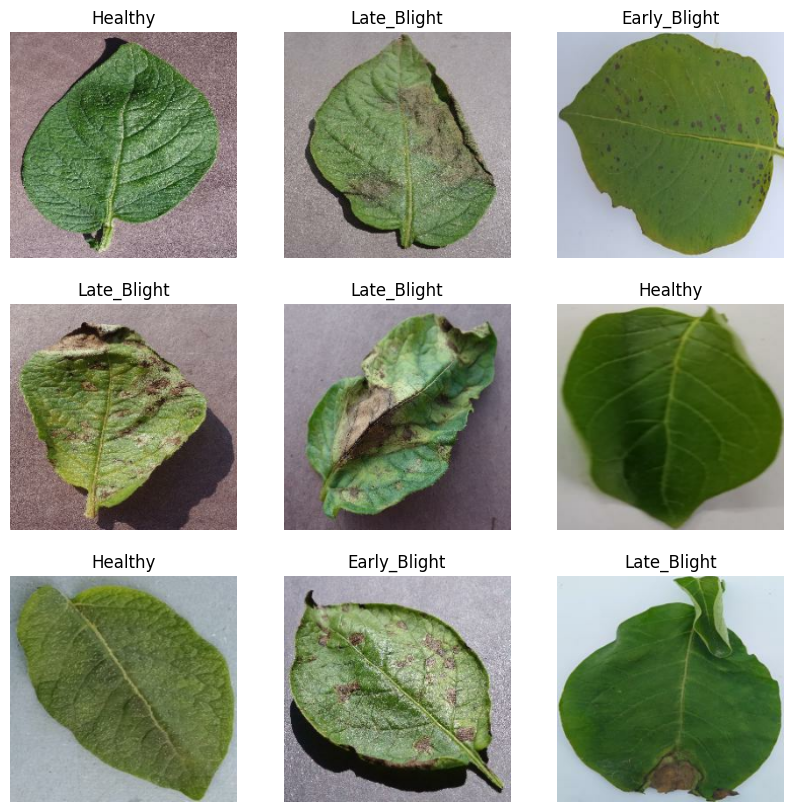

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in ds_train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [ ]:
ds_train = ds_train.map(lambda x, y: (data_augmentation(x, training=True), y))
ds_train = ds_train.map(lambda x, y: (preprocess_input(x), y))


ds_val = ds_val.map(lambda x, y: (preprocess_input(x), y))
ds_test = ds_test.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
ds_val = ds_val.cache().prefetch(buffer_size=AUTOTUNE)
ds_test = ds_test.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

for layer in base_model.layers[:-20]:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 256s 147ms/step - accuracy: 0.7780 - loss: 0.5731 - val_accuracy: 0.8630 - val_loss: 0.3316 - learning_rate: 1.0000e-05
Epoch 2/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - accuracy: 0.9429 - loss: 0.1632 - val_accuracy: 0.9183 - val_loss: 0.2099 - learning_rate: 1.0000e-05
Epoch 3/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9707 - loss: 0.0885 - val_accuracy: 0.9351 - val_loss: 0.1730 - learning_rate: 1.0000e-05
Epoch 4/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.9845 - loss: 0.0494 - val_accuracy: 0.9423 - val_loss: 0.1661 - learning_rate: 1.0000e-05
Epoch 5/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9905 - loss: 0.0309 - val_accuracy: 0.9495 - val_loss: 0.1696 - learning_rate: 1.0000e-05
Epoch 6/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.9955 - loss: 0.0190 - val_accuracy: 0.9471 - val_loss: 0.1911 - learning_rate: 1.0000e-05
Epoch 7/15
403/403 ━━━━━━━━━━━━━━━━━━━━ 46s 1

In [ ]:
test_loss, test_acc = model.evaluate(ds_test)
print("Test accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 436ms/step - accuracy: 0.9309 - loss: 0.1762
Test accuracy: 0.9308642148971558


In [ ]:
def predict_keras(model, img_path, class_names):
    import numpy as np
    from tensorflow.keras.preprocessing import image
    from tensorflow.keras.applications.resnet50 import preprocess_input

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    return class_names[np.argmax(preds)]

In [ ]:
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [ ]:
img_path=r"/content/images.jpg"
predict_keras(model,img_path,class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


'Early_Blight'

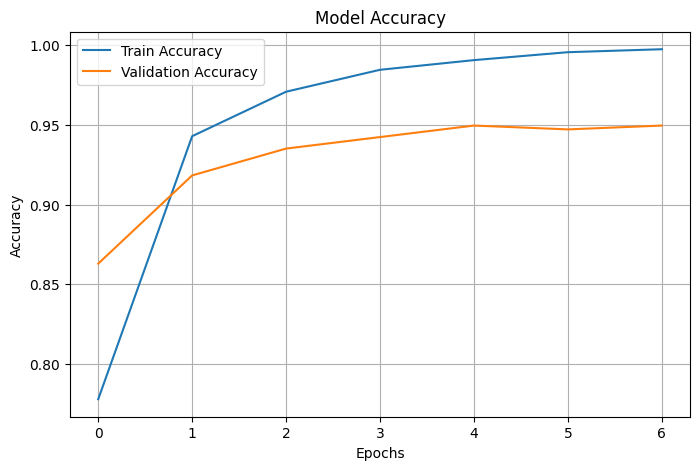

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

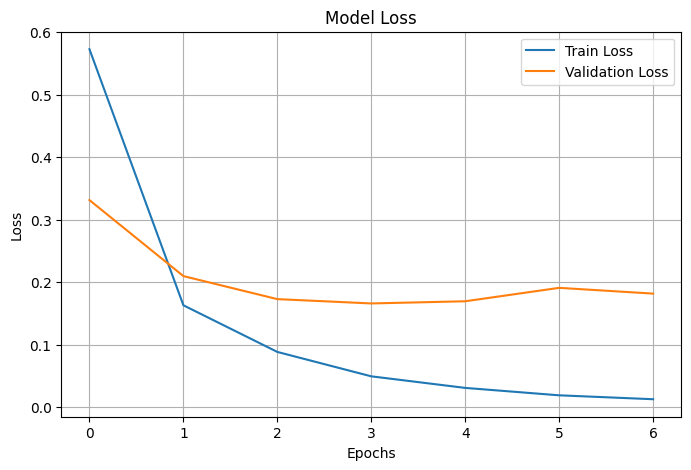

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
predict_tflite(interpreter,img_path,class_names)

'Potato___Late_blight'

In [ ]:
model.save("/content/potato_resnet_model.keras")

In [ ]:
model = tf.keras.models.load_model(r"C:\Users\DELL\OneDrive\Desktop\potato_disease\models\potato_resnet_model.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

# Save TFLite model
with open("name.tflite", "wb") as f:
    f.write(tflite_model)

print("Converted successfully!")